# Loadings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# ----
sns.set_theme(
    style="ticks",
    palette="deep",
    font_scale=1.1,
    rc={
        'figure.figsize': (12, 9),
        'figure.facecolor': 'white',
        'axes.spines.right': False,
        'axes.spines.top': False,
        'grid.alpha': 0.3,
        'axes.grid': True,
    }
    )
# ----
import warnings
warnings.filterwarnings('ignore')

In [2]:
customers = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv")
customers.head(1)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP


In [3]:
orders = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv", 
                     parse_dates=['order_estimated_delivery_date',
                                  'order_delivered_customer_date',
                                  'order_delivered_carrier_date',
                                  'order_approved_at',
                                  'order_purchase_timestamp'])
orders.head(1)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18


In [4]:
geolocation = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_geolocation_dataset.csv")
geolocation.head(1)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP


In [5]:
items = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv",
                   parse_dates=['shipping_limit_date'])
items.head(1)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29


In [6]:
payments = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv")
payments.head(1)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33


In [7]:
reviews = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv",
                     parse_dates=['review_creation_date'])
reviews.head(1)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59


In [8]:
products = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv",
                     )
products.head(1)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0


In [9]:
sellers = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_sellers_dataset.csv"
                     )
sellers.head(1)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP


In [10]:
category_translation = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/product_category_name_translation.csv"
                     )
category_translation.head(1)

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty


****

# Data Cleaning

## Data Check Function

In [11]:
def data_check(df, name=''):
    print("-"*20)
    print(f"Checking: {name} Data.")
    print("-"*20)

    
    print(f"{"#"*10} {name}: Null Values {"#"*10}")
    print(df.isnull().sum())
    print("-"*20)

    
    print(f"{"#"*10} {name}: Duplicates Values {"#"*10}")
    print(f"Duplicates Count: {df.duplicated().sum()}")
    print("-"*20)

    
    print(f"{"#"*10} {name}: Data Types {"#"*10}")
    print(df.dtypes)
    print("-"*20)

    
    print(f"{"#"*10} {name}: Outliers (Describe) {"#"*10}")
    print(df.describe())
    print("-"*20)

## Customers

In [12]:
data_check(customers, name='customers')


--------------------
Checking: customers Data.
--------------------
########## customers: Null Values ##########
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
--------------------
########## customers: Duplicates Values ##########
Duplicates Count: 0
--------------------
########## customers: Data Types ##########
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object
--------------------
########## customers: Outliers (Describe) ##########
       customer_zip_code_prefix
count              99441.000000
mean               35137.474583
std                29797.938996
min                 1003.000000
25%                11347.000000
50%                24416.000000
75%                58900.000000
max                99990.000000
----------------

**Clean Dataset**

****

## Orders

In [13]:
data_check(orders, name='orders')


--------------------
Checking: orders Data.
--------------------
########## orders: Null Values ##########
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
--------------------
########## orders: Duplicates Values ##########
Duplicates Count: 0
--------------------
########## orders: Data Types ##########
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object
--------------------
######

In [14]:
print("=== DATA QUALITY REPORT ===")
print(f"Total orders: {len(orders):,}")
print(f"Orders with null delivery date: {orders['order_delivered_customer_date'].isna().sum():,}")
print(f"% of orders not yet delivered: {orders['order_delivered_customer_date'].isna().mean():.2%}")


=== DATA QUALITY REPORT ===
Total orders: 99,441
Orders with null delivery date: 2,965
% of orders not yet delivered: 2.98%


**o	didn’t Remove Null Values Due to other valuable information, even a declined order has value, while some contexts require only completed orders will be handled individually.**

****

## Geolocation

In [15]:
data_check(geolocation,'Geolocation')

--------------------
Checking: Geolocation Data.
--------------------
########## Geolocation: Null Values ##########
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64
--------------------
########## Geolocation: Duplicates Values ##########
Duplicates Count: 261831
--------------------
########## Geolocation: Data Types ##########
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                object
geolocation_state               object
dtype: object
--------------------
########## Geolocation: Outliers (Describe) ##########
       geolocation_zip_code_prefix  geolocation_lat  geolocation_lng
count                 1.000163e+06     1.000163e+06     1.000163e+06
mean                  3.657417e+04    -2.117615e+01    -4.639054e+01
std                   3.054934e+04     5.715866

**o	Reasonable **Duplicates** as one Location Can Be used Multiple times.**

****

## Items

In [16]:
data_check(items,"Items")

--------------------
Checking: Items Data.
--------------------
########## Items: Null Values ##########
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
--------------------
########## Items: Duplicates Values ##########
Duplicates Count: 0
--------------------
########## Items: Data Types ##########
order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 float64
dtype: object
--------------------
########## Items: Outliers (Describe) ##########
       order_item_id            shipping_limit_date          price  \
count  112650.000000                         112650  112650.000000   
mean        1.197834  2018-01-07 15:36:52.192685312     120.653739  

**Clean Data**

****

## Payments

In [17]:
data_check(payments,'Payments')

--------------------
Checking: Payments Data.
--------------------
########## Payments: Null Values ##########
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64
--------------------
########## Payments: Duplicates Values ##########
Duplicates Count: 0
--------------------
########## Payments: Data Types ##########
order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object
--------------------
########## Payments: Outliers (Describe) ##########
       payment_sequential  payment_installments  payment_value
count       103886.000000         103886.000000  103886.000000
mean             1.092679              2.853349     154.100380
std              0.706584              2.687051     217.494064
min              1.000000              0.000000       0.000000
25%              1.000000    

**Clean Data**

****

## Reviews

In [18]:
data_check(reviews,'Reviews')

--------------------
Checking: Reviews Data.
--------------------
########## Reviews: Null Values ##########
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64
--------------------
########## Reviews: Duplicates Values ##########
Duplicates Count: 0
--------------------
########## Reviews: Data Types ##########
review_id                          object
order_id                           object
review_score                        int64
review_comment_title               object
review_comment_message             object
review_creation_date       datetime64[ns]
review_answer_timestamp            object
dtype: object
--------------------
########## Reviews: Outliers (Describe) ##########
       review_score           review_creation_date
count  99224.000000                          99224
mean       4

****

## Products

In [19]:
data_check(products,'Products')

--------------------
Checking: Products Data.
--------------------
########## Products: Null Values ##########
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64
--------------------
########## Products: Duplicates Values ##########
Duplicates Count: 0
--------------------
########## Products: Data Types ##########
product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object
--------------------
########## Products: Outliers (Describ

In [20]:
products[products.isnull().any(axis=1)]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


In [21]:
products.fillna("Unknown",inplace=True)

In [22]:
products[products.isnull().any(axis=1)]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm


****

## Sellers

In [23]:
data_check(sellers,'Sellers')

--------------------
Checking: Sellers Data.
--------------------
########## Sellers: Null Values ##########
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64
--------------------
########## Sellers: Duplicates Values ##########
Duplicates Count: 0
--------------------
########## Sellers: Data Types ##########
seller_id                 object
seller_zip_code_prefix     int64
seller_city               object
seller_state              object
dtype: object
--------------------
########## Sellers: Outliers (Describe) ##########
       seller_zip_code_prefix
count             3095.000000
mean             32291.059451
std              32713.453830
min               1001.000000
25%               7093.500000
50%              14940.000000
75%              64552.500000
max              99730.000000
--------------------


****
****

# Master Dataset

## Merge Customer and Order Data on customer_id

In [24]:
customer_order_df = customers.merge(orders,how='left',on='customer_id')
customer_order_df.shape

(99441, 12)

## Merge Customer_Order Data with Payments, and Items on order_id as (merged_df2)

In [25]:
merged_df2 = customer_order_df.merge(reviews,how='left',on='order_id').merge(payments,how='left',on='order_id').merge(items,how='left',on='order_id')
merged_df2.shape

(119143, 28)

## Merge (merged_df2) with Products on product_id as (merged_df3)

In [26]:
merged_df3 = merged_df2.merge(products,how='left',on='product_id')
merged_df3.shape

(119143, 36)

## Merge (merged_df3) with Sellers on seller_id as (merged_df4)

In [27]:
merged_df4 = merged_df3.merge(sellers,how='left',on='seller_id')
merged_df4.shape

(119143, 39)

In [28]:
## Merge Customer and Order Data on customer_id as customer_order_df
customer_order_df = customers.merge(orders,how='left',on='customer_id')
print(customer_order_df.shape)
## Merge Customer_Order Data with Payments, and Items on order_id as (merged_df2)
merged_df2 = customer_order_df.merge(reviews,how='left',on='order_id').merge(payments,how='left',on='order_id').merge(items,how='left',on='order_id')
print(merged_df2.shape)
## Merge (merged_df2) with Products on product_id as (merged_df3)
merged_df3 = merged_df2.merge(products,how='left',on='product_id')
print(merged_df3.shape)
## Merge (merged_df3) with Sellers on seller_id as (merged_df4)
merged_df4 = merged_df3.merge(sellers,how='left',on='seller_id')
print(merged_df4.shape)
## Will Not Merge Geolocation as its Overlapping between seller and customer

(99441, 12)
(119143, 28)
(119143, 36)
(119143, 39)


In [29]:
# DATA QUALITY: Row Expansion Audit
print("=== ROW EXPANSION AUDIT ===")
print(f"Unique customers: {merged_df4['customer_unique_id'].nunique():,}")
print(f"Unique orders: {merged_df4['order_id'].nunique():,}")
print(f"Total rows: {len(merged_df4):,}")
print(f"Rows per order (avg): {len(merged_df4) / merged_df4['order_id'].nunique():.2f}")

# Which tables caused expansion?
print("\n=== TABLE CARDINALITY CHECK ===")
print(f"Reviews per order (max): {reviews.groupby('order_id').size().max()}")
print(f"Payments per order (max): {payments.groupby('order_id').size().max()}")
print(f"Items per order (max): {items.groupby('order_id').size().max()}")

=== ROW EXPANSION AUDIT ===
Unique customers: 96,096
Unique orders: 99,441
Total rows: 119,143
Rows per order (avg): 1.20

=== TABLE CARDINALITY CHECK ===
Reviews per order (max): 3
Payments per order (max): 29
Items per order (max): 21


**Some Orders Have Multiple Items, Reviews, and Payments that's what caused increase in total order**

**Geolocation Dataset left for seperate Analysis as it contains location of both seller and customer**

****

****
****

# Analysis

## What is the conversion funnel from customer signup to first purchase, and where is the biggest drop-off?

In [30]:
customer_order_df.head(1)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05


In [31]:
# Step 1: Signup (Total Unique Customers)
total_customers = customer_order_df['customer_unique_id'].nunique()
total_customers

96096

In [32]:
repeat_customers = customer_order_df.groupby('customer_unique_id')['order_id'].count().reset_index()
repeat_customers.head(1)

,customer_unique_id,order_id
0,0000366f3b9a7992bf8c76cfdf3221e2,1


In [33]:
# Step 2: First buyers (Customer Who Made at least one orders)
first_order_customers = repeat_customers[repeat_customers['order_id'] >=1].shape[0]
# Step 3: Returning buyers (Customer With 2 or more Orders)
second_order_customers = repeat_customers[repeat_customers['order_id'] >=2].shape[0]
# Step 4: Potential Loyal buyers (Customer With 3 or more Orders)
third_order_customers = repeat_customers[repeat_customers['order_id'] >=3].shape[0]
# Step 5: Loyal Customers buyers (Customer With 4 or more Orders)
loyal_customers = repeat_customers[repeat_customers['order_id'] >=4].shape[0]


In [34]:
customers= [total_customers,
            first_order_customers,
            second_order_customers,
            third_order_customers,
            loyal_customers]

funnel = {'step':['Step 1: Total Customer',
                     'Step 2: First buyers',
                     'Step 3: Returning buyers',
                     'Step 4: Potential Loyal buyers',
                    'Step 5: Loyal Customers'],
'customers':customers,
'pct % of total':[i/total_customers*100 for i in customers]}

In [35]:
funnel_df = pd.DataFrame.from_dict(funnel)
funnel_df.to_csv("funnel_df.csv",index=False)
print(funnel_df.head())

                             step  customers  pct % of total
0          Step 1: Total Customer      96096      100.000000
1            Step 2: First buyers      96096      100.000000
2        Step 3: Returning buyers       2997        3.118756
3  Step 4: Potential Loyal buyers        252        0.262238
4         Step 5: Loyal Customers         49        0.050991


In [36]:
# conversion rate: second_order_customers / total_customers
conversion_rate = second_order_customers/total_customers

In [37]:
print(f"Total customers: {total_customers:,}")
print(f"Repeat buyers: {second_order_customers:,}")
print(f"Repeat purchase rate: {conversion_rate:.2%}")

Total customers: 96,096
Repeat buyers: 2,997
Repeat purchase rate: 3.12%


**A 2.91% repeat purchase rate suggests this is a discovery-heavy marketplace (customers buy once, then leave).**

**This is common when: (1) product selection is fragmented across sellers, (2) trust/quality varies, or (3) there's no loyalty program.**

In [38]:
# Calculate ACTUAL AOV from the dataset
aov = merged_df4['payment_value'].mean()  # Or calculate from order items
print(f"Actual AOV: {aov:.2f} BRL")

# Calculate realistic revenue opportunity
lost_customers = total_customers - second_order_customers
revenue_opportunity = lost_customers * aov * 1.5  # Assume repeat customers spend 1.5x
print(f"Revenue opportunity: {revenue_opportunity:,.0f} BRL")

Actual AOV: 172.74 BRL
Revenue opportunity: 24,122,203 BRL


**Step 3 holds the biggest drop with 96.88% drop which equals potential 24M BRL Revenue (based on 172 BRL AOV)"**

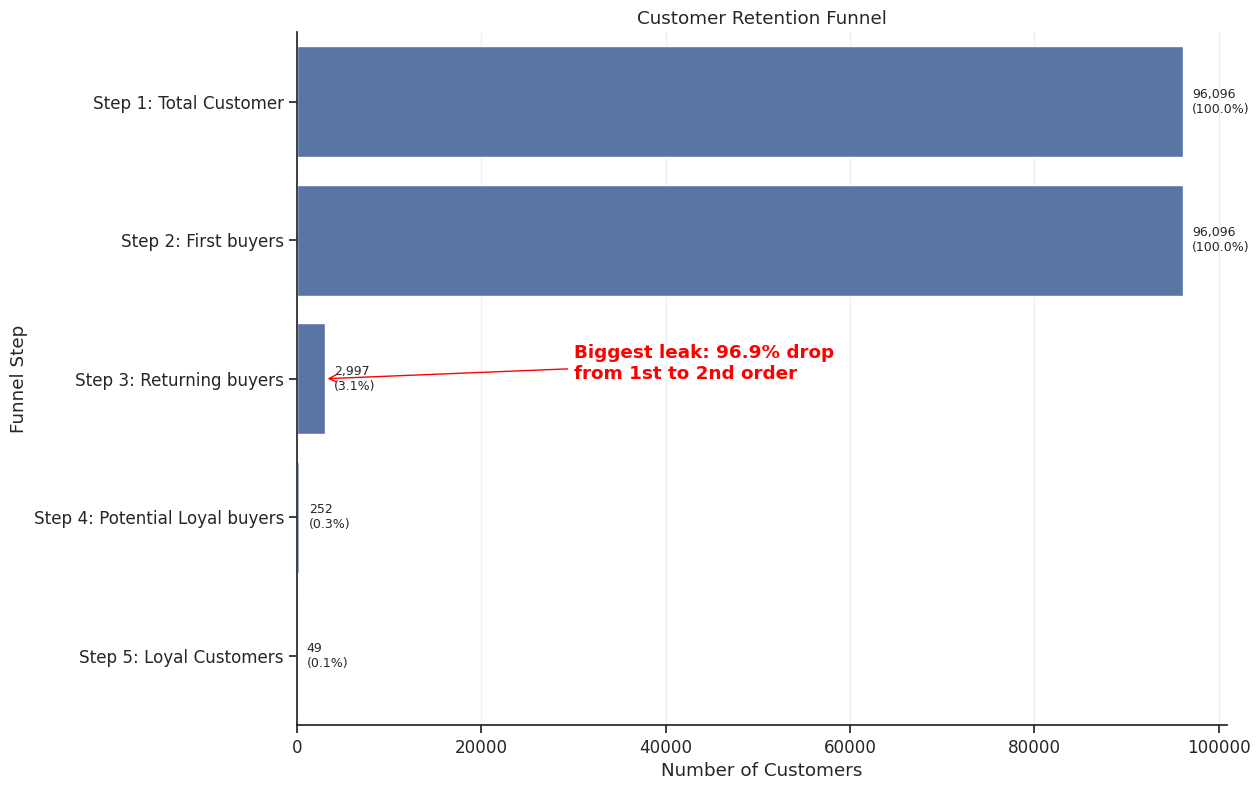

In [39]:
ax= sns.barplot(funnel_df, x='customers',y='step')

# Add percentage labels
for i, (step, count, pct) in enumerate(zip(funnel_df['step'], funnel_df['customers'], funnel_df['pct % of total'])):
    ax.text(count + 1000, i, f'{count:,}\n({pct:.1f}%)', va='center', fontsize=9)

# Highlight the biggest drop
ax.annotate('Biggest leak: 96.9% drop\nfrom 1st to 2nd order', 
            xy=(3000, 2), xytext=(30000, 2),
            arrowprops=dict(arrowstyle='->', color='red'),
            color='red', fontweight='bold')

# Add grid lines for readability
ax.grid(axis='x', alpha=0.3)
    
plt.xlabel('Number of Customers')
plt.ylabel('Funnel Step')
plt.title('Customer Retention Funnel')
plt.savefig('Funnel_chart.png', dpi=300)  # Save for portfolio


### Geographic Segmentation

In [40]:
city_repeat = customer_order_df.groupby('customer_city').agg(
    total_customers=('customer_unique_id', 'nunique'),
    repeat_customers=('order_id', lambda x: (x.groupby(customer_order_df['customer_unique_id']).count() >= 2).sum())
).reset_index()

city_repeat['repeat_rate'] = city_repeat['repeat_customers'] / city_repeat['total_customers']
city_repeat['ratio_to_avg'] = city_repeat['repeat_rate'] / city_repeat['repeat_rate'].mean()

# Filter to cities with ≥100 customers
top_cities = city_repeat[city_repeat['total_customers'] >= 100].sort_values('repeat_rate', ascending=False).head(10)
print(top_cities)

             customer_city  total_customers  repeat_customers  repeat_rate  \
2815            petropolis              220                14     0.063636   
208   aparecida de goiania              104                 6     0.057692   
2995          pouso alegre              124                 7     0.056452   
2936          ponta grossa              135                 7     0.051852   
2098               limeira              181                 9     0.049724   
2501         nova friburgo              145                 7     0.048276   
1390       franco da rocha              104                 5     0.048077   
2986           porto velho              105                 5     0.047619   
2167                  mage              106                 5     0.047170   
900          caxias do sul              213                10     0.046948   

      ratio_to_avg  
2815      2.369219  
208       2.147918  
2995      2.101726  
2936      1.930474  
2098      1.851244  
2501      1.797

**Customers in Petropolis  have 2.37x higher repeat rate than average. Hypothesis: Better delivery infrastructure or higher product quality in this region**

In [41]:
# Find cities with worst repeat rates (min 100 customers)
worst_cities = city_repeat[city_repeat['total_customers'] >= 100].sort_values('repeat_rate').head(5)
print(worst_cities)

# Calculate revenue impact of improving worst performers
avg_repeat_rate = city_repeat['repeat_rate'].mean()
lost_opportunity = worst_cities['total_customers'].sum() * (avg_repeat_rate - worst_cities['repeat_rate'].mean())
print(f"Lost repeat customers in bottom 5 cities: {lost_opportunity:.0f}")

             customer_city  total_customers  repeat_customers  repeat_rate  \
2240               marilia              195                 1     0.005128   
1810               itapevi              169                 1     0.005917   
1382                franca              160                 1     0.006250   
1463  governador valadares              140                 1     0.007143   
1190           divinopolis              136                 1     0.007353   

      ratio_to_avg  
2240      0.190926  
1810      0.220299  
1382      0.232691  
1463      0.265933  
1190      0.273754  
Lost repeat customers in bottom 5 cities: 16


****

In [42]:
# RECOMMENDATIONS:
# 1. Launch 'Buy Again' feature on homepage for top 20% repeat categories
#          → Expected: +15% repeat rate in 90 days
#          → Owner: Product Team
#          → Effort: Medium (2-week sprint)"

# 2. Implement post-purchase email sequence with related product recommendations
#     → Expected: +10% second-order conversion
#     → Owner: Marketing
#     → Effort: Low (1 week)"

# 3. offer Special Discount for customers on their second order.
#     → Expected: +10% second-order conversion
#     → Owner: Marketing
#     → Effort: Low (1 week)"

# 4. Create A Loyalty program where customers stack points based on their orders.
#     → Expected: +15% second-order conversion
#     → Owner: Product Team
#     → Effort: High (2-3 weeks)"

****
****

## Does Categories Influence Customer Return?

In [43]:
prod_cat = merged_df4[merged_df4['order_status']=='delivered'] [['customer_unique_id','order_id',
                                                                  'order_purchase_timestamp',
                                                                  'product_category_name']]
prod_cat.head(1)

,customer_unique_id,order_id,order_purchase_timestamp,product_category_name
0,861eff4711a542e4b93843c6dd7febb0,00e7ee1b050b8499577073aeb2a297a1,2017-05-16 15:05:35,moveis_escritorio


In [44]:
# 1. For each customer, their FIRST order and product category
df_repeat = prod_cat.sort_values('order_purchase_timestamp').groupby('customer_unique_id').head(1)
df_repeat

,customer_unique_id,order_id,order_purchase_timestamp,product_category_name
25367,830d5b7aaa3b6f1e9ad63703bec97d23,bfbd0f9bdef84302105ad712db648a6c,2016-09-15 12:16:38,beleza_saude
46382,32ea3bdedab835c3aa6cb68ce66565ef,3b697a20d9e427646d92567910af6d57,2016-10-03 09:44:50,relogios_presentes
66097,2f64e403852e6893ae37485d5fcacdaf,be5bc2f0da14d8071e2d45451ad119d9,2016-10-03 16:56:50,esporte_lazer
9308,61db744d2f835035a5625b59350c6b63,a41c8759fbe7aab36ea07e038b2d4465,2016-10-03 21:13:36,esporte_lazer
67308,8d3a54507421dbd2ce0a1d58046826e0,d207cc272675637bfed0062edffd0818,2016-10-03 22:06:03,moveis_decoracao
...,...,...,...,...
74827,7a22d14aa3c3599238509ddca4b93b01,52018484704db3661b98ce838612b507,2018-08-29 12:25:59,brinquedos
101429,5c58de6fb80e93396e2f35642666b693,0b223d92c27432930dfe407c6aea3041,2018-08-29 14:18:23,moveis_cozinha_area_de_servico_jantar_e_jardim
585,7febafa06d9d8f232a900a2937f04338,168626408cb32af0ffaf76711caae1dc,2018-08-29 14:18:28,beleza_saude
59755,b701bebbdf478f5500348f03aff62121,03ef5dedbe7492bdae72eec50764c43f,2018-08-29 14:52:00,artigos_de_festas


In [45]:
# total orders per customer 
customer_order_counts = merged_df4.groupby('customer_unique_id')['order_id'].count().reset_index()
customer_order_counts.columns = ['customer_unique_id', 'total_orders']

# Merge order counts back into df_repeat
df_with_counts = df_repeat.merge(customer_order_counts, on='customer_unique_id', how='left')

# Flag repeat customers (1 = yes, 0 = no)
df_with_counts['is_repeat'] = (df_with_counts['total_orders'] > 1).astype(int)

# Group by first category and calculate repeat rate
category_repeat = df_with_counts.groupby('product_category_name').agg(
    total_customers=('customer_unique_id', 'count'),
    repeat_customers=('is_repeat', 'sum'),
    repeat_rate=('is_repeat', 'mean'),
).reset_index()


# Filter to categories with ≥500 customers
category_repeat_filtered = category_repeat[category_repeat['total_customers']>500].sort_values(by='repeat_rate',
                                                                                               ascending=False)

# Translating Category Names
cat_map = category_translation.set_index('product_category_name')['product_category_name_english']

category_repeat_filtered['product_category_name'] = category_repeat_filtered['product_category_name'].map(cat_map)


# Top 3 Categories by Repeat Rate
print(category_repeat_filtered.sort_values(by='repeat_rate', ascending=False).head(3))

print("="*100)

# Bottom 3 Categories by Repeat Rate
print(category_repeat_filtered.sort_values(by='repeat_rate', ascending=False).tail(3))

   product_category_name  total_customers  repeat_customers  repeat_rate
55       furniture_decor             5928              1575     0.265688
56      office_furniture             1223               279     0.228128
41          garden_tools             3331               719     0.215851
   product_category_name  total_customers  repeat_customers  repeat_rate
13                  toys             3674               373     0.101524
67         watches_gifts             5319               522     0.098139
27            cool_stuff             3461               292     0.084369


- **Top 3 Categories score x2.48 Avg Repeat Rate *(0.236)* to Bottom 3 Categories avg *(0.095)***
- **The Top Categories Are More Shifted on the Essential Side Needed for Each Houshold, while the bottom categories are more like a secondary thing that can be overlooked.**

In [46]:
# revenue opportunity for bottom 3 categories
bottom_3 = category_repeat_filtered.sort_values('repeat_rate').head(3)
lost_repeat_customers = bottom_3['total_customers'].sum() * (category_repeat['repeat_rate'].mean() - bottom_3['repeat_rate'].mean())
revenue_opportunity = lost_repeat_customers * aov

print(f"Lost repeat customers in bottom 3 categories: {lost_repeat_customers:.0f}")
print(f"Revenue opportunity: {revenue_opportunity:,.0f} BRL (~${revenue_opportunity/5:,.0f} USD)")

Lost repeat customers in bottom 3 categories: 752
Revenue opportunity: 129,817 BRL (~$25,963 USD)


In [47]:
# Test: Do "essential" categories have higher AOV or lower return rates?
# Merge with items to get order value per category
category_value = merged_df4.groupby('product_category_name').agg(
    avg_order_value=('price', 'mean'),
    avg_items_per_order=('order_item_id', 'mean')
).reset_index()

# Merge with your repeat rate data
category_analysis = category_repeat.merge(category_value, on='product_category_name', how='left')

# Check correlation: Does higher AOV correlate with higher repeat rate?
corr = category_analysis['repeat_rate'].corr(category_analysis['avg_order_value'])
print(f"Correlation: AOV vs Repeat Rate = {corr:.3f}")

Correlation: AOV vs Repeat Rate = -0.151


****
****

## Cohort Analysis (Retention Over Time)

In [48]:
# customer fires Appearance
customer_first = merged_df4.groupby('customer_unique_id').agg(first_order=('order_purchase_timestamp','min'),
                                                             total_orders=('order_id','count')).reset_index()

customer_first['year_month'] = customer_first['first_order'].dt.to_period('M').astype('str')

customer_first['repeat_customers'] = (customer_first['total_orders'] > 1).astype(int)
customer_first

,customer_unique_id,first_order,total_orders,year_month,repeat_customers
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,2018-05,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,2018-05,0
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,2017-03,0
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,2017-10,0
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,2017-11,0
...,...,...,...,...,...
96091,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:36,2,2017-06,1
96092,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:56,1,2017-12,0
96093,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:16,1,2017-02,0
96094,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:41,1,2018-05,0


In [49]:
# unique customers per cohort month
cohort_month = customer_first.groupby("year_month").agg(unique_customers=("customer_unique_id",'nunique'),
                                                       repeat_customers=('repeat_customers','sum')).reset_index()

cohort_month['repeat_pct%']=round(cohort_month['repeat_customers']/cohort_month['unique_customers']*100, 2)
cohort_month=cohort_month[cohort_month['unique_customers'] >300]
cohort_month

,year_month,unique_customers,repeat_customers,repeat_pct%
1,2016-10,321,53,16.51
3,2017-01,764,160,20.94
4,2017-02,1752,284,16.21
5,2017-03,2636,449,17.03
6,2017-04,2352,408,17.35
7,2017-05,3596,636,17.69
8,2017-06,3139,510,16.25
9,2017-07,3894,669,17.18
10,2017-08,4184,716,17.11
11,2017-09,4130,675,16.34


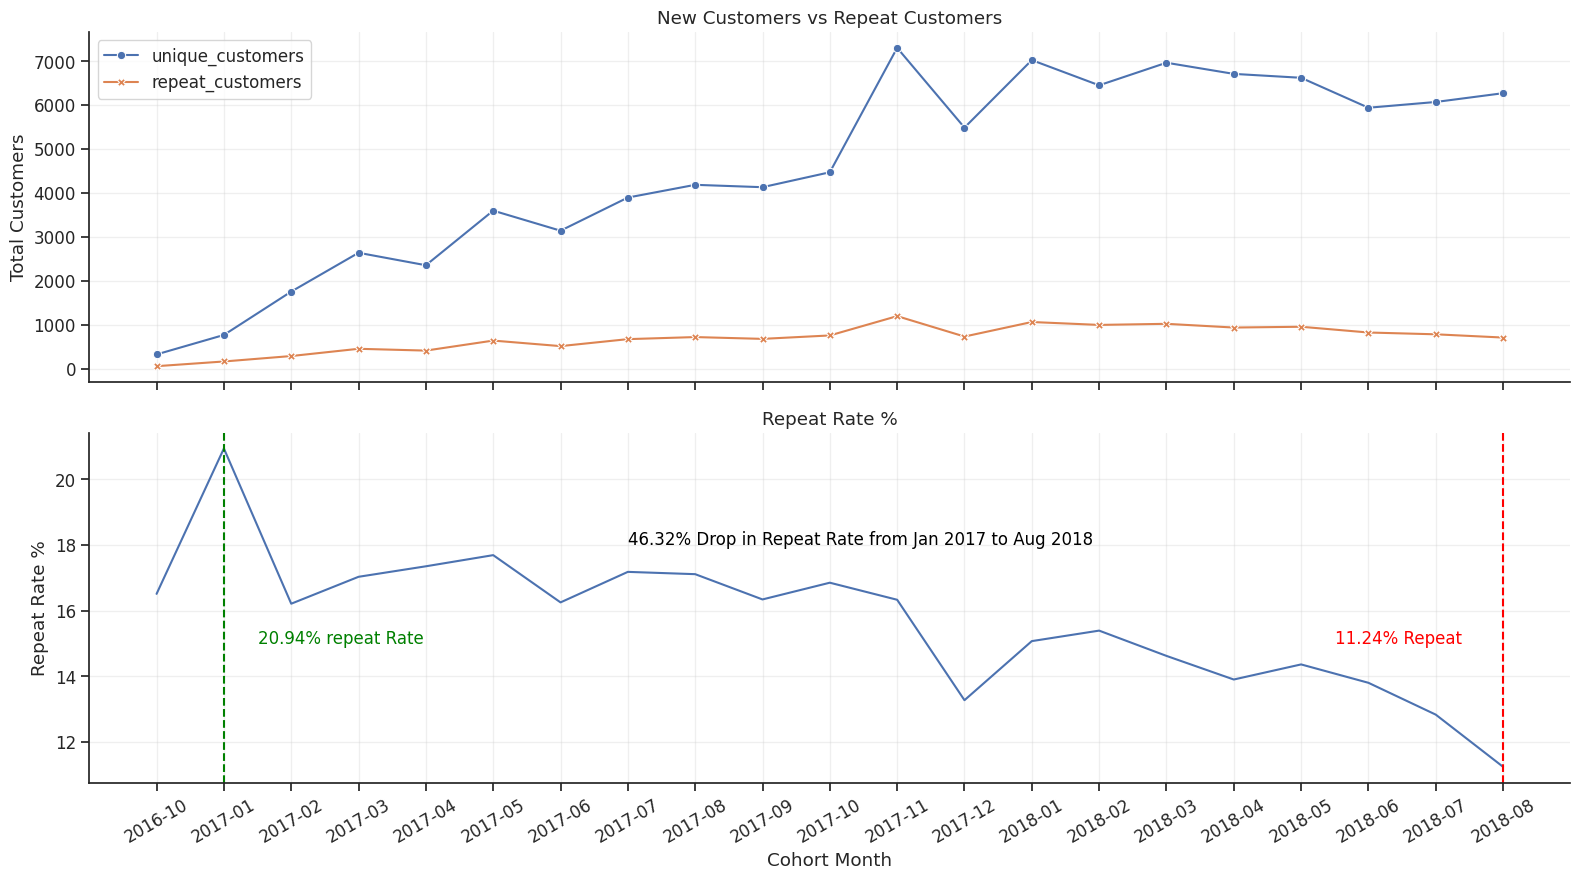

In [50]:
fig, ax= plt.subplots(2,1,figsize=(16,9),sharex=True)

sns.lineplot(data=cohort_month.set_index('year_month')[['unique_customers', 'repeat_customers']], ax=ax[0],
             markers=True, dashes=False)

ax[0].set_xticklabels(labels=cohort_month['year_month'], rotation=30)

ax[0].set_ylabel('Total Customers')

ax[0].set_title("New Customers vs Repeat Customers")

sns.lineplot(data=cohort_month.set_index('year_month')['repeat_pct%'], ax=ax[1],
             markers=True, dashes=False)

ax[1].set_xticklabels(labels=cohort_month['year_month'], rotation=30)

ax[1].set_ylabel('Repeat Rate %')

ax[1].set_xlabel('Cohort Month')
ax[1].axvline(x=1, color='green', linestyle='--')
ax[1].text(x=1.5, y=15, s="20.94% repeat Rate", fontsize=12, color='green')


ax[1].text(x=7, y=18, s="46.32% Drop in Repeat Rate from Jan 2017 to Aug 2018", fontsize=12, color='black')


ax[1].axvline(x=20, color='red', linestyle='--')
ax[1].text(x=17.5, y=15, s="11.24% Repeat", fontsize=12, color='red')

ax[1].set_title("Repeat Rate %")

plt.tight_layout()


plt.savefig('New Customers vs Repeat Customers with Repeat %.png',dpi=300)
plt.show()

- **Insight:** **it's observable that the overall repeat rate is Declining, 46.32% Drop in Repeat Rate from Jan 2017 to Aug 2018**

  
- **Action:** **Gather customer feedback often, If you want to know what is and isn’t working for your customers, it helps to hear it straight from the horse’s mouth**
*     → Expected: +10% second-order conversion
*     → Owner: Customer Service
*     → Effort: Low (1 week)

In [51]:
from scipy import stats

# Calculate linear trend
x = range(len(cohort_month))
y = cohort_month['repeat_pct%']
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print(f"Trend: {slope:.3f}% per month (negative = declining)")
print(f"R-squared: {r_value**2:.3f} (how much of variance is explained by time)")
print(f"P-value: {p_value:.4f} (<0.05 = statistically significant)")

Trend: -0.282% per month (negative = declining)
R-squared: 0.698 (how much of variance is explained by time)
P-value: 0.0000 (<0.05 = statistically significant)


****
****

##  Repeat Customer Revenue Impact Calculator

In [136]:
USD_RATE = 5.0
def revenue_impact_calc(target_repeat_rate, aov, current_repeat_rate, total_customers):
    
    current_repeat_customers = total_customers * conversion_rate
    current_repeat_revenue = total_customers * current_repeat_rate * aov
    
    target_repeat_customers = total_customers * target_repeat_rate
    target_repeat_revenue = target_repeat_customers * aov  # Assuming 1 extra order each

    additional_revenue = target_repeat_revenue - current_repeat_revenue

    df = pd.DataFrame({'repeat_customers':[current_repeat_customers, target_repeat_customers],
                      'repeat_rate':[round(current_repeat_rate*100, 2), round(target_repeat_rate*100, 2)],
                      'revenue':[current_repeat_revenue, target_repeat_revenue]})
    
    print(f"Current repeat customers: {total_customers * current_repeat_rate:.0f}")
    print(f"Current repeat customers revenue: {current_repeat_revenue:,.0f} BRL (~${current_repeat_revenue/USD_RATE:,.0f} USD)\n")
    
    print(f"Target repeat customers: {target_repeat_customers:.0f}")
    print(f"Additional repeat customers: {target_repeat_customers - current_repeat_customers:.0f}")
    print(f"Target repeat revenue (1 extra order each): {target_repeat_revenue:,.0f} BRL (~${target_repeat_revenue/USD_RATE:,.0f} USD)")
    print(f"Additional revenue (1 extra order each): {additional_revenue:,.0f} BRL (~${additional_revenue/USD_RATE:,.0f} USD)")

    # Barplot
    custom_palette = {round(current_repeat_rate*100, 2): "#C51E3A", round(target_repeat_rate*100, 2): "#40E0D0"}
    ax = sns.barplot(df, x='repeat_rate',y='revenue',hue='repeat_rate',palette=custom_palette)
    plt.title(f"What if we improve repeat rate to {round(target_repeat_rate*100, 2)}%?")
    
    for i, v in enumerate(df['revenue']):
        ax.text(i, v + 10000, f"{v:,.0f} BRL", ha='center')
        
    plt.text(x=-0.1, y=target_repeat_revenue - target_repeat_revenue*0.05, s=f"Notice {round((additional_revenue/current_repeat_revenue)*100,2 )}% Increase In Revenue", fontsize=12, color='green')
   
    plt.savefig(f"What if we improve repeat rate to {round(target_repeat_rate*100, 2)}.png")


Current repeat customers: 2997
Current repeat customers revenue: 517,687 BRL (~$103,537 USD)

Target repeat customers: 4805
Additional repeat customers: 1808
Target repeat revenue (1 extra order each): 829,958 BRL (~$165,992 USD)
Additional revenue (1 extra order each): 312,271 BRL (~$62,454 USD)


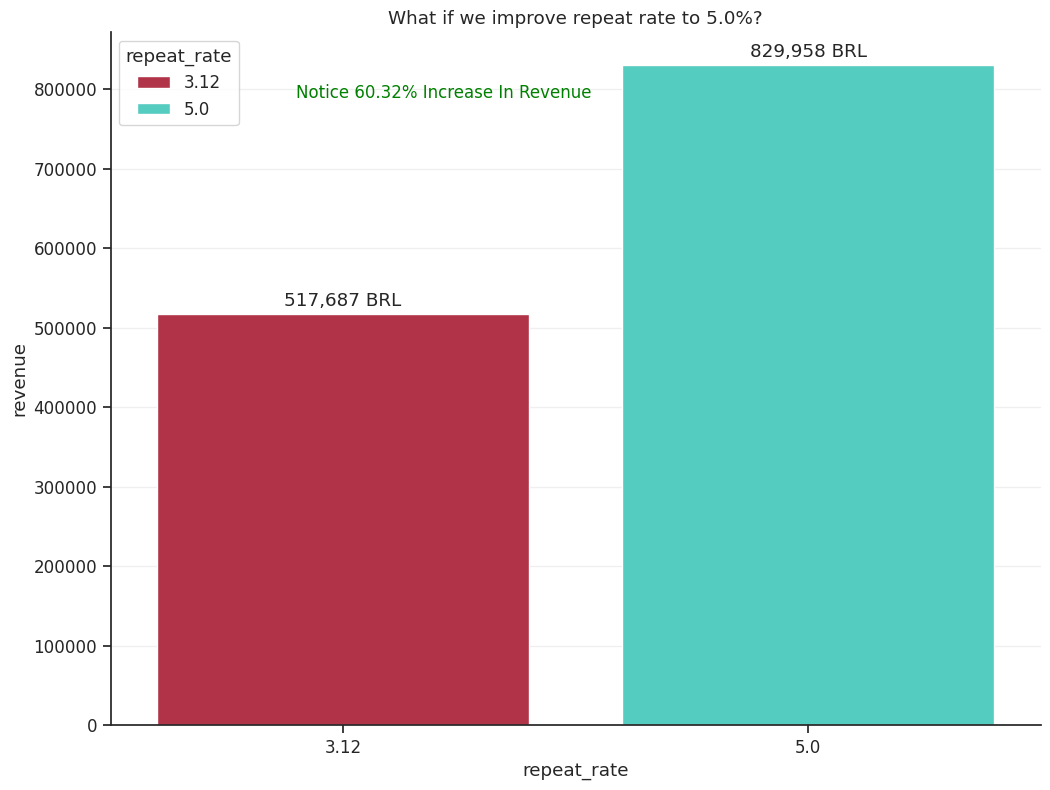

In [137]:
revenue_impact_calc(0.05, aov, conversion_rate, total_customers)

****